In [1]:
from pymutspec import draw
import pandas as pd
import plotly.express as px
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.pyplot import figure
import numpy as np
from scipy.stats import ttest_ind, wilcoxon, mannwhitneyu, f_oneway, zscore, spearmanr
from scipy.spatial.distance import pdist, cdist
import re

# Swap that to True if you want to invert nucls
INVERT = True
#Change to true to filter mutspecs by num of total muts and num of mut types
FILTER = True

PATH_TO_METADATA = '../data/msMetaData.tsv'
PATH_TO_CODONTABLE = '../data/codontable_midori_Blattodea.csv'


In [2]:
metadata = pd.read_csv(PATH_TO_METADATA, sep='\t', index_col=0)
blattodea_meta = metadata.loc[metadata['Order'] == 'Blattodea_85823']

In [3]:
terms_meta = [] 
terms_meta.append(blattodea_meta.loc[blattodea_meta['Family'] == 'Rhinotermitidae_36985'])
terms_meta.append(blattodea_meta.loc[blattodea_meta['Family'] == 'Termitidae_46569'])
terms_meta = pd.concat(terms_meta)
terms_meta.reset_index(inplace=True)

cocks_meta = []
cocks_meta.append(blattodea_meta.loc[blattodea_meta['Family'] == 'Blattidae_6974'])
cocks_meta.append(blattodea_meta.loc[blattodea_meta['Family'] == 'Cryptocercidae_36982'])
cocks_meta.append(blattodea_meta.loc[blattodea_meta['Family'] == 'Ectobiidae_1049651'])
cocks_meta = pd.concat(cocks_meta)
cocks_meta.reset_index(inplace=True)

In [4]:
blattodea_codontable = pd.read_csv(PATH_TO_CODONTABLE, index_col=0)
blattodea_codontable.loc[blattodea_codontable["Taxonomy"] == "['Eukaryota_2759', 'Arthropoda_6656', 'Insecta_50557', 'Blattodea_85823', 'Cryptocercidae_36982']",
                                        "Workers"] = 'Sub'
blattodea_codontable['Species_name'] = list(map(lambda sp: f'{sp.split("_")[0]}_{sp.split("_")[1]}', blattodea_codontable['Species_name']))
blattodea_codontable['Workers'] = blattodea_codontable['Workers'].map({1.0 : 'Termites w/ workers', 0.0 : 'Termites w/o workers', "Sub" : 'Sub-social Cryptocercus'})
blattodea_codontable['Workers'] = blattodea_codontable['Workers'].fillna('Cockroaches')

term_codontable = blattodea_codontable[blattodea_codontable['Workers'].isin(['Termites w/ workers', 'Termites w/o workers'])]

cocks_codontable = blattodea_codontable[blattodea_codontable['Workers'].isin(['Cockroaches', 'Sub-social Cryptocercus'])]

In [5]:
blattodea_codontable.columns

Index(['Species_name', 'GenbankID', 'Taxonomy', 'Workers', 'Gene_name',
       'Gene_start_end_and_trend', 'GeneID', 'Aminoacids_from_genbank',
       'Translated_aminoacids_by_Python', 'Not_standart_codons',
       'Wrong_amino_num', 'Wrong_nucl_num', 'wrong_amino_%', 'Sequence',
       'mtDNA_length', 'nA', 'nT', 'nC', 'nG', 'nNA', '%A', '%T', '%C', '%G',
       '%NA', 'neutralA', 'neutralG', 'neutralC', 'neutralT', 'Neutral_count',
       'TTT', 'TTC', 'TTA', 'TTG', 'TCT', 'TCC', 'TCA', 'TCG', 'TAT', 'TAC',
       'TGT', 'TGC', 'TGA', 'TGG', 'CTT', 'CTC', 'CTA', 'CTG', 'CCT', 'CCC',
       'CCA', 'CCG', 'CAT', 'CAC', 'CAA', 'CAG', 'CGT', 'CGC', 'CGA', 'CGG',
       'ATT', 'ATC', 'ATA', 'ATG', 'ACT', 'ACC', 'ACA', 'ACG', 'AAT', 'AAC',
       'AAA', 'AAG', 'AGT', 'AGC', 'AGA', 'AGG', 'GTT', 'GTC', 'GTA', 'GTG',
       'GCT', 'GCC', 'GCA', 'GCG', 'GAT', 'GAC', 'GAA', 'GAG', 'GGT', 'GGC',
       'GGA', 'GGG', 'TAA', 'TAG'],
      dtype='object')

In [6]:
new_blattodea_codontable = blattodea_codontable[blattodea_codontable['Workers'].isin(['Cockroaches', 'Sub-social Cryptocercus', 'Termites w/ workers', 'Termites w/o workers'])]
new_blattodea_codontable = new_blattodea_codontable[['Workers', 'neutralA', 'neutralT', 'neutralG', 'neutralC', 'Gene_name', 'Neutral_count']]

In [7]:
new_blattodea_codontable = new_blattodea_codontable[new_blattodea_codontable['Gene_name'].isin(['ND1', 'ND4', 'ND4L', 'ND5'])]

In [8]:
new_blattodea_codontable = new_blattodea_codontable.reset_index(drop=True)

In [9]:
new_blattodea_codontable['fr_neut_A'] = new_blattodea_codontable['neutralA'] / new_blattodea_codontable['Neutral_count']
new_blattodea_codontable['fr_neut_T'] = new_blattodea_codontable['neutralT'] / new_blattodea_codontable['Neutral_count']
new_blattodea_codontable['fr_neut_G'] = new_blattodea_codontable['neutralG'] / new_blattodea_codontable['Neutral_count']
new_blattodea_codontable['fr_neut_C'] = new_blattodea_codontable['neutralC'] / new_blattodea_codontable['Neutral_count']

new_blattodea_codontable['Organism'] = ''
new_blattodea_codontable.loc[new_blattodea_codontable['Workers'] == 'Cockroaches', 'Organism'] = 'Cockroaches'
new_blattodea_codontable.loc[new_blattodea_codontable['Workers'] == 'Sub-social Cryptocercus', 'Organism'] = 'Sub-social Cryptocercus'
new_blattodea_codontable.loc[new_blattodea_codontable['Workers'] == 'Termites w/ workers', 'Organism'] = 'Termites with workers'
new_blattodea_codontable.loc[new_blattodea_codontable['Workers'] == 'Termites w/o workers', 'Organism'] = 'Termites without workers'

In [10]:
new_blattodea_codontable = new_blattodea_codontable[['Organism', 'fr_neut_A', 'fr_neut_T', 'fr_neut_G', 'fr_neut_C']]
new_blattodea_codontable.to_csv('../data/blattodea_nuc_content.csv')

In [11]:
new_blattodea_codontable.rename(columns={
    'fr_neut_A': 'Neutral A',
    'fr_neut_T': 'Neutral T',
    'fr_neut_G': 'Neutral G',
    'fr_neut_C': 'Neutral C'
}, inplace=True)

In [12]:
data_long = new_blattodea_codontable.melt(id_vars=['Organism'], value_vars=['Neutral A', 'Neutral T', 'Neutral G', 'Neutral C'],
                      var_name='Nuc_name', value_name='Nuc_value')

In [13]:
data_long

,Organism,Nuc_name,Nuc_value
0,Termites with workers,Neutral A,0.039062
1,Termites with workers,Neutral A,0.091463
2,Termites with workers,Neutral A,0.031250
3,Termites with workers,Neutral A,0.061404
4,Termites with workers,Neutral A,0.065041
...,...,...,...
6347,Termites without workers,Neutral C,0.035398
6348,Termites without workers,Neutral C,0.000000
6349,Termites without workers,Neutral C,0.034247
6350,Termites without workers,Neutral C,0.034483


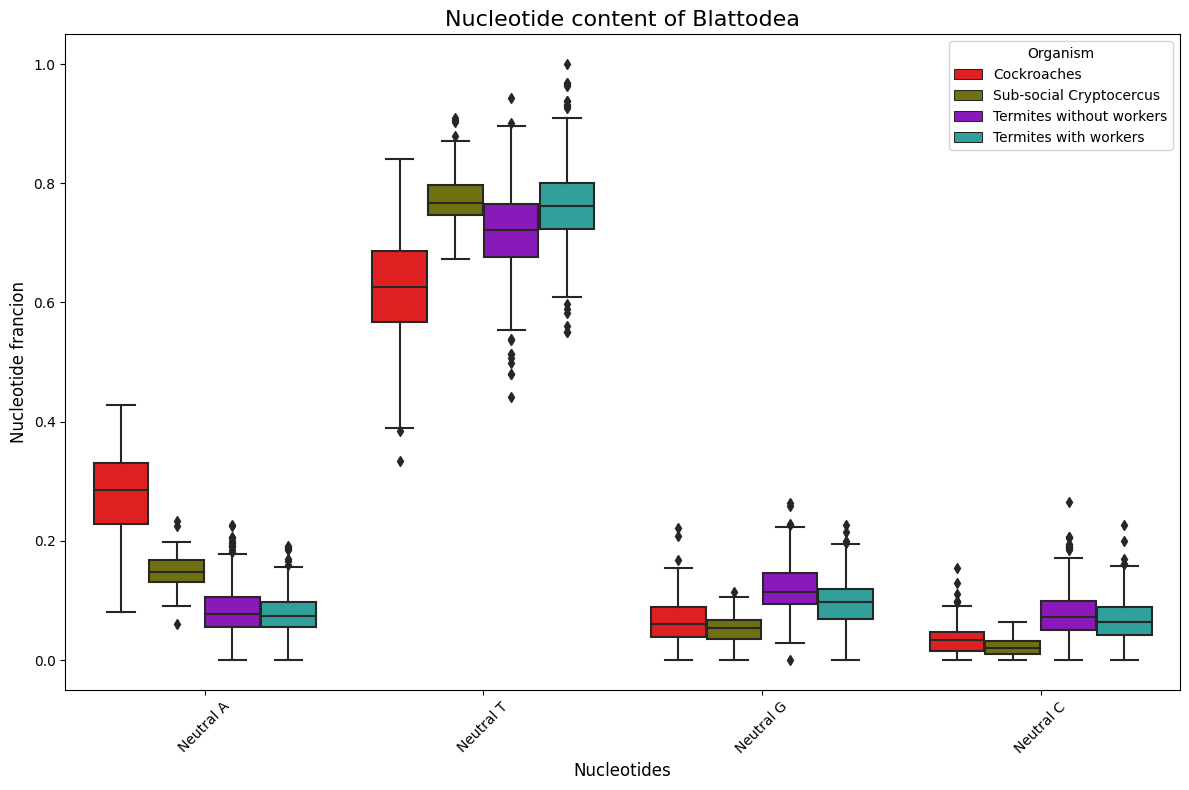

In [14]:
palette = {
    'Cockroaches': 'red',
    'Sub-social Cryptocercus': 'olive',
    'Termites with workers': 'lightseagreen',
    'Termites without workers': 'darkviolet'
}

organism_order = ['Cockroaches', 'Sub-social Cryptocercus', 'Termites without workers', 'Termites with workers']
gene_order = ['Neutral A', 'Neutral T', 'Neutral G', 'Neutral C']

plt.figure(figsize=(12, 8))

# Создаем boxplot
sns.boxplot(data=data_long, x='Nuc_name', y='Nuc_value', hue='Organism', palette=palette,  order=gene_order, hue_order=organism_order)

# Настроим оси и заголовки
plt.title('Nucleotide content of Blattodea', fontsize=16)
plt.xlabel('Nucleotides', fontsize=12)
plt.ylabel('Nucleotide francion', fontsize=12)
plt.xticks(rotation=45)
plt.legend(title='Organism')

# Показываем график
plt.tight_layout()
plt.savefig('../figures/nuc_content_boxplot.pdf')
plt.show()
plt.close()